# Titanic: what the model actually learned

A narrative pass over the dataset and the model trained on it.

**This notebook contains no analysis logic.** Every computation is imported from
`src/zepto/analytics`, which is typed, unit-tested, and covered in CI. The notebook
supplies the argument and the charts; the code it calls is the same code that runs
in `zepto-train`.

That split is deliberate. In the previous version of this project the analysis lived
*only* in notebooks, which meant none of it could be imported, tested, or reviewed
except by re-running cells and reading output. Here the notebook is a thin reading
surface over tested modules, so it cannot quietly disagree with what ships.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

from zepto.analytics.datasets import load_titanic
from zepto.analytics.features import build_features, leakage_score
from zepto.analytics.model_card import compare_to_baseline, evaluate_by_group
from zepto.analytics.settings import AnalyticsSettings
from zepto.analytics.training import split_data, train_and_evaluate
from zepto.core.errors import LeakageError
from zepto.core.logging import configure_logging

# The modules emit structured operational logs, which are for operators rather than
# readers. Quietened here so the narrative is not interleaved with them.
configure_logging(level="WARNING")

# Works whether the notebook is run from the repository root or from notebooks/.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

settings = AnalyticsSettings(dataset_path=REPO_ROOT / "data" / "samples" / "titanic.csv")
pd.set_option("display.width", 100)

## The data

891 passengers from the 1912 sinking, with survival outcome and a handful of
attributes. Loading goes through a schema contract, so a truncated file or a renamed
column fails here with a specific message rather than surfacing as a confusing error
three layers later.

In [2]:
frame = load_titanic(settings=settings)
print(f"{len(frame)} passengers, {frame.shape[1]} columns")
print(f"survival rate: {frame['survived'].mean():.1%}")
frame.head()

891 passengers, 15 columns
survival rate: 38.4%


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## What is missing

Three columns have gaps, and they need different treatment. `deck` is missing for
roughly three quarters of rows -- imputing it would fabricate more than it preserves,
so it is dropped. `age` is missing for about a fifth and is median-imputed inside the
pipeline, fit on training rows only.

In [3]:
missing = (frame.isna().mean() * 100).round(1)
missing[missing > 0].sort_values(ascending=False).to_frame("% missing")

,% missing
deck,77.2
age,19.9
embarked,0.2
embark_town,0.2


## The pattern that dominates everything

Survival splits sharply on sex, and again on ticket class within it. Every model
trained here ends up rediscovering this, and most of what looks like model skill is
this table.

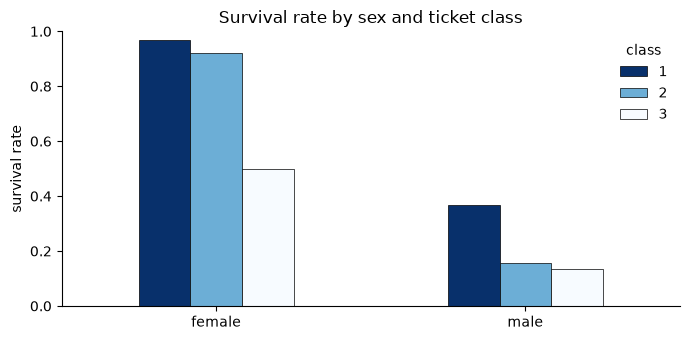

pclass,1,2,3
sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [4]:
rates = frame.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 3.5))
rates.plot(kind="bar", ax=ax, rot=0, colormap="Blues_r", edgecolor="black", linewidth=0.5)
ax.set_ylabel("survival rate")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="class", frameon=False)
ax.set_title("Survival rate by sex and ticket class")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

rates.round(3)

## The trap in this dataset

The frame contains a column called `alive`, which is `survived` written as yes/no.
Leave it in and every classifier scores near-perfectly while having learned nothing.
It is silent: nothing crashes, the metrics simply look excellent.

The feature builder refuses it two ways. It is named in the known-leakage list, and
independently, any feature predicting the target at or above 0.99 accuracy is
rejected whether or not anyone anticipated it. Below, the known list is emptied so the
second guard has to catch it on its own.

In [5]:
target = frame["survived"]
scores = {
    column: leakage_score(frame[column], target, cardinality_limit=20)
    for column in ["alive", "sex", "pclass", "age", "fare"]
}
display(pd.Series(scores, name="leakage score").sort_values(ascending=False).round(4))

# Known-leakage list emptied: the behavioural guard must catch it unaided.
try:
    build_features(frame, settings=AnalyticsSettings(leakage_columns=()))
except LeakageError as error:
    print(f"refused: {error}")

alive     1.0000
sex       0.7868
pclass    0.6790
fare      0.2573
age       0.0772
Name: leakage score, dtype: float64

refused: feature predicts the target almost perfectly and is treated as leakage (columns=['alive'], scores={'alive': 1.0}, threshold=0.99)


## Features

What survives: the target is removed, leaking columns are refused, and columns that
duplicate or derive from others are dropped -- `class` repeats `pclass`, `who` and
`adult_male` derive from sex and age, `embark_town` repeats `embarked`, `alone`
derives from the family counts.

In [6]:
features, target = build_features(frame, settings=settings)
print(f"kept {list(features.columns)}")
print(f"dropped {sorted(set(frame.columns) - set(features.columns))}")

kept ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
dropped ['adult_male', 'alive', 'alone', 'class', 'deck', 'embark_town', 'survived', 'who']


## Training

One stratified split, three classifiers, identical preprocessing. Preprocessing sits
inside the pipeline, so fitting cannot see the test rows -- that is structural rather
than a convention someone has to remember.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(random_state=42),
}

rows = []
for name, estimator in models.items():
    _, result = train_and_evaluate(estimator, features, target, model_name=name, settings=settings)
    rows.append({"model": name, **vars(result.metrics)})

pd.DataFrame(rows).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logistic_regression,0.804,0.793,0.667,0.724,0.844
decision_tree,0.816,0.790,0.710,0.748,0.790
random_forest,0.816,0.800,0.696,0.744,0.829


## The question worth asking

Around 80% accuracy reads as respectable. But the right comparison is not zero, it is
the simplest thing that could possibly work: predict the majority outcome within each
sex-and-class cell. That needs no model at all.

In [8]:
pipeline, _ = train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    features,
    target,
    model_name="logistic_regression",
    settings=settings,
)
data = split_data(features, target, settings=settings)

comparison = compare_to_baseline(
    pipeline,
    data.features_train,
    data.target_train,
    data.features_test,
    data.target_test,
    ("sex", "pclass"),
)

pd.DataFrame(
    [
        {
            "": "sex x class lookup",
            "accuracy": comparison.baseline_accuracy,
            "f1": comparison.baseline_f1,
        },
        {
            "": "logistic regression",
            "accuracy": comparison.model_accuracy,
            "f1": comparison.model_f1,
        },
        {"": "gain", "accuracy": comparison.accuracy_gain, "f1": comparison.f1_gain},
    ]
).set_index("").round(4)

,accuracy,f1
,,
sex x class lookup,0.7765,0.6923
logistic regression,0.8045,0.7244
gain,0.0279,0.0321


In [9]:
print(f"the model agrees with the lookup table on {comparison.agreement:.1%} of test rows")

the model agrees with the lookup table on 92.7% of test rows


So the model contributes roughly three accuracy points over a two-column lookup, and
makes the same call as that lookup on more than nine rows in ten. The headline number
is mostly the base rates of sex and class.

This is the single most useful thing to know about the model, and it is invisible from
accuracy alone.

## Who it fails

Aggregate metrics average over people. Broken out by sex and class *together*, the
model turns out to make categorical calls: it predicts death for every man in second
and third class, and survival for almost every woman in first and second.

Sliced one attribute at a time this does not show up -- both sexes post around 0.80
accuracy. It only appears at the intersection, which is the usual reason this kind of
failure goes unnoticed.

In [10]:
groups = evaluate_by_group(pipeline, data.features_test, data.target_test, ("sex", "pclass"))

table = pd.DataFrame(
    [
        {
            "group": g.label,
            "n": g.size,
            "base rate": round(g.base_rate, 3),
            "accuracy": round(g.accuracy, 3),
            "precision": round(g.precision, 3),
            "recall": round(g.recall, 3),
        }
        for g in groups
    ]
).set_index("group")
table

,n,base rate,accuracy,precision,recall
group,,,,,
overall,179,0.385,0.804,0.793,0.667
sex=female,61,0.738,0.803,0.811,0.956
sex=male,118,0.203,0.805,0.600,0.125
pclass=1,45,0.556,0.756,0.850,0.680
pclass=2,34,0.588,0.882,0.944,0.850
pclass=3,100,0.240,0.800,0.600,0.500
sex=female & pclass=1,15,0.933,0.933,0.933,1.000
sex=female & pclass=2,18,0.944,0.944,0.944,1.000
sex=female & pclass=3,28,0.500,0.643,0.600,0.857


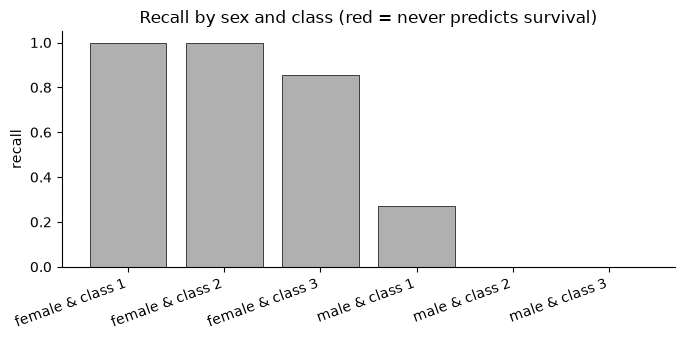

In [11]:
intersections = [g for g in groups if " & " in g.label]
labels = [g.label.replace("sex=", "").replace("pclass=", "class ") for g in intersections]

fig, ax = plt.subplots(figsize=(7, 3.5))
colours = ["#b0b0b0" if g.recall > 0 else "#c1442e" for g in intersections]
ax.bar(labels, [g.recall for g in intersections], color=colours, edgecolor="black", linewidth=0.5)
ax.set_ylabel("recall")
ax.set_ylim(0, 1.05)
ax.set_title("Recall by sex and class (red = never predicts survival)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## What this model is

A slightly smoothed lookup table on sex and ticket class, reporting 80% accuracy that
comes mostly from those two base rates, and issuing categorical verdicts by
demographic group.

That is a defensible object for studying a historical event. It is not something to
deploy against people, and the model card stored with each trained version says so in
those terms, alongside the disaggregated table above.

Reproduce any of this with:

```bash
zepto-train    # train and version all three models
zepto-card     # regenerate the model card from the stored artifact
```